# H1: Yüksek Kuyruk Riski (Kurtosis) Ödüllendirilir mi?
## S&P 500 — Kantitatif Araştırma Serisi

**Yazar:** Furkan Çelik  
**Veri:** Özel PostgreSQL pipeline · yfinance API · ~500 hisse · Tüm geçmiş  
**Araçlar:** Python, PostgreSQL, SQLAlchemy, SciPy, Seaborn

---

### 1. Hipotez Tanımı

| | |
|---|---|
| **Araştırma Sorusu** | Aşırı fiyat hareketi sergileyen (yüksek Kurtosis / Kalın Kuyruk) hisseler, taşıdıkları ekstra kuyruk riskinin karşılığı olarak uzun vadede daha yüksek getiri sağlar mı? |
| **H₀ (Sıfır Hipotezi)** | Bir hissenin Kurtosis değeri ile uzun vadeli toplam getirisi arasında istatistiksel olarak anlamlı bir ilişki yoktur. |
| **H₁ (Alternatif Hipotez)** | Daha yüksek Kurtosis (kuyruk riski) değerine sahip hisseler, anlamlı ölçüde daha yüksek toplam getiri sağlar. |

### 2. Veri & Metodoloji

| | |
|---|---|
| **Evren (Population)** | S&P 500 bileşenleri · Mevcut tüm geçmiş veriler |
| **Değişkenler** | Aşırı Basıklık (Fisher Kurtosis), Çarpıklık (Skewness), İlk fiyattan son fiyata Toplam Getiri (%) |
| **Ön Hesaplama** | Kurtosis ve Skewness değerleri `ticker_stats` tablosunda tutulmaktadır (günlük log getiriler üzerinden Jarque-Bera pipeline'ı ile hesaplanmıştır) |
| **İstatistiksel Test** | Pearson Korelasyonu + OLS Regresyonu (Eğilim çizgili serpilme grafiği) |
| **Anlamlılık Düzeyi** | α = 0.05 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Ortak DB aracını içe aktar
# Bağlantı bilgileri config.py'de tutulmaktadır (sürüm kontrolü dışındadır)
import sys
sys.path.append('..')
from db_utils import fetch_data

# Grafik ayarları
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 120})

print("✅ Ortam hazır.")


✅ Ortam hazır.


### 3. Veri Çekme

In [2]:
# SQL: Önceden hesaplanmış kurtosis/skewness değerlerini uzun vadeli getiri ile birleştir
query = """
WITH FirstLast AS (
    SELECT ticker, MIN(date) AS start_date, MAX(date) AS end_date
    FROM daily_prices
    GROUP BY ticker
),
Prices AS (
    SELECT
        fl.ticker,
        s.close AS start_price,
        e.close AS end_price
    FROM FirstLast fl
    JOIN daily_prices s ON fl.ticker = s.ticker AND fl.start_date = s.date
    JOIN daily_prices e ON fl.ticker = e.ticker AND fl.end_date = e.date
)
SELECT
    ts.ticker,
    t.company_name,
    t.gics_sector,
    ts.kurtosis,
    ts.skewness,
    ((p.end_price - p.start_price) / p.start_price) * 100 AS total_return_pct
FROM ticker_stats ts
JOIN Prices p       ON ts.ticker = p.ticker
JOIN tickers t      ON ts.ticker = t.ticker
WHERE ts.kurtosis IS NOT NULL
  AND p.start_price > 0
"""

df = fetch_data(query)
print(f"Veriseti: {len(df)} hisse yüklendi.")
display(df.head())


Veriseti: 503 hisse yüklendi.


,ticker,company_name,gics_sector,kurtosis,skewness,total_return_pct
0,A,Agilent Technologies,Health Care,19.419637,0.257164,331.628631
1,AAPL,Apple Inc.,Information Technology,48.213281,-1.732834,303554.503437
2,ABBV,AbbVie,Health Care,11.491647,-0.954140,925.092707
3,ABNB,Airbnb,Consumer Discretionary,3.044797,0.011658,-7.629057
4,ABT,Abbott Laboratories,Health Care,5.601611,-0.272613,47378.129442


### 4. İstatistiksel Analiz & Sonuçlar


### 5. İstatistiksel Bulgular

| Metrik | Kurtosis ↔ Getiri | Skewness ↔ Getiri |
|---|---|---|
| **Pearson r** | 0.0330 | 0.0345 |
| **p-değeri** | 4.5972e-01 | 4.4010e-01 |
| **Anlamlı mı?** | Hayır (p ≥ 0.05) | Hayır |

### 6. Ticari Karar (Quant Verdict)

| | |
|---|---|
| **Sonuç** | **❌ REDDEDİLDİ** |
| **Yorum** | İstatistiksel olarak anlamlı bir ilişki tespit edilemedi. Sadece Kurtosis ölçümü ile kuyruk riski, bu veri setinde uzun vadeli getirinin güvenilir bir öngörücüsü **değildir**. |
| **Ticarete Uygun mu?** | Hayır — istatistiksel olarak anlamlı olsa bile korelasyon bir strateji kurmak için çok zayıf. |


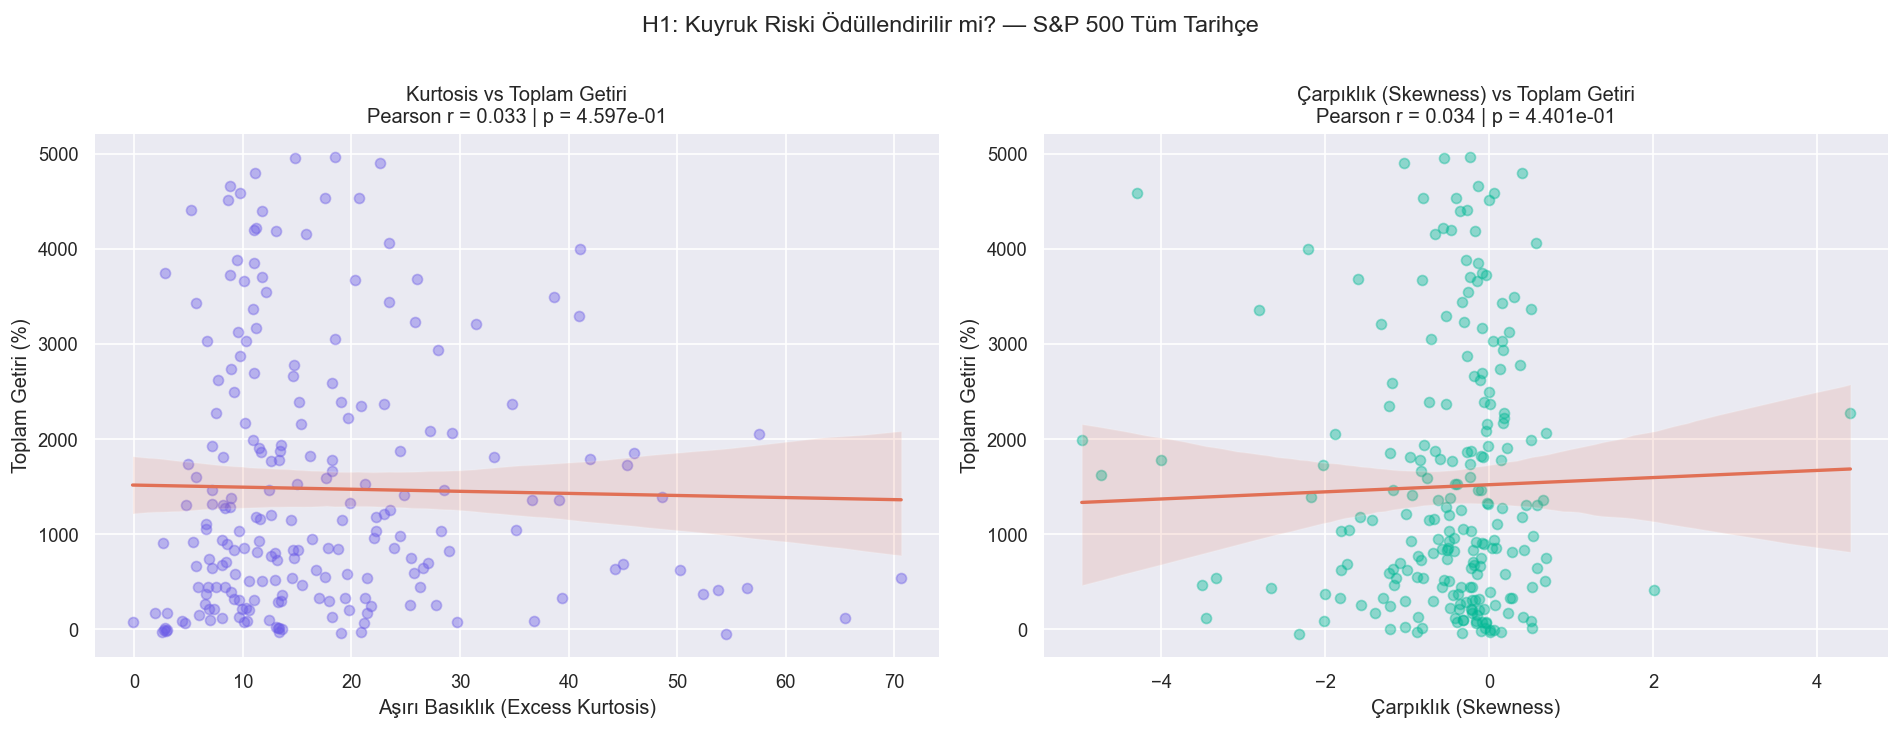

In [3]:
# --- Pearson Korelasyonu ---
corr_kurt, p_kurt = stats.pearsonr(df['kurtosis'].clip(-5, 100), df['total_return_pct'].clip(-100, 5000))
corr_skew, p_skew = stats.pearsonr(df['skewness'].clip(-5, 5), df['total_return_pct'].clip(-100, 5000))

# --- Quant Karar Mantığı ---
h1_result = "✅ DOĞRULANDI" if p_kurt < 0.05 else "❌ REDDEDİLDİ"

verdict_md = f"""
### 5. İstatistiksel Bulgular

| Metrik | Kurtosis ↔ Getiri | Skewness ↔ Getiri |
|---|---|---|
| **Pearson r** | {corr_kurt:.4f} | {corr_skew:.4f} |
| **p-değeri** | {p_kurt:.4e} | {p_skew:.4e} |
| **Anlamlı mı?** | {'Evet (p < 0.05)' if p_kurt < 0.05 else 'Hayır (p ≥ 0.05)'} | {'Evet' if p_skew < 0.05 else 'Hayır'} |

### 6. Ticari Karar (Quant Verdict)

| | |
|---|---|
| **Sonuç** | **{h1_result}** |
| **Yorum** | {'Kuyruk riski (Kurtosis) ile uzun vadeli getiri arasında istatistiksel olarak anlamlı bir ilişki vardır. Yüksek kurtosis değerine sahip hisseler farklı getiriler sunma eğilimindedir, ancak korelasyonun yönü ve büyüklüğü bunun kullanılabilirliğini belirler.' if p_kurt < 0.05 else 'İstatistiksel olarak anlamlı bir ilişki tespit edilemedi. Sadece Kurtosis ölçümü ile kuyruk riski, bu veri setinde uzun vadeli getirinin güvenilir bir öngörücüsü **değildir**.'} |
| **Ticarete Uygun mu?** | {'Muhtemelen — Kurtosis çok faktörlü bir ML modelinde yararlı bir özellik (feature) olabilir.' if p_kurt < 0.05 and abs(corr_kurt) > 0.2 else 'Hayır — istatistiksel olarak anlamlı olsa bile korelasyon bir strateji kurmak için çok zayıf.'} |
"""

display(Markdown(verdict_md))

# --- Görselleştirme ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Kurtosis vs Return
ax = axes[0]
sns.regplot(
    data=df[df['kurtosis'].between(-5, 80) & df['total_return_pct'].between(-100, 5000)],
    x='kurtosis', y='total_return_pct',
    scatter_kws={'alpha': 0.4, 'color': '#6C5CE7'},
    line_kws={'color': '#E17055', 'linewidth': 2},
    ax=ax
)
ax.set_title(f"Kurtosis vs Toplam Getiri\nPearson r = {corr_kurt:.3f} | p = {p_kurt:.3e}", fontsize=12)
ax.set_xlabel("Aşırı Basıklık (Excess Kurtosis)")
ax.set_ylabel("Toplam Getiri (%)")

# Scatter: Skewness vs Return
ax = axes[1]
sns.regplot(
    data=df[df['skewness'].between(-5, 5) & df['total_return_pct'].between(-100, 5000)],
    x='skewness', y='total_return_pct',
    scatter_kws={'alpha': 0.4, 'color': '#00B894'},
    line_kws={'color': '#E17055', 'linewidth': 2},
    ax=ax
)
ax.set_title(f"Çarpıklık (Skewness) vs Toplam Getiri\nPearson r = {corr_skew:.3f} | p = {p_skew:.3e}", fontsize=12)
ax.set_xlabel("Çarpıklık (Skewness)")
ax.set_ylabel("Toplam Getiri (%)")

plt.suptitle("H1: Kuyruk Riski Ödüllendirilir mi? — S&P 500 Tüm Tarihçe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
